# Stage 5 — Conditional Diffusion Model

A class-conditional **denoising diffusion probabilistic model (DDPM)** that generates
128x128 log-mel bird-song spectrograms for the three target species
(American Robin, Northern Cardinal, Song Sparrow).

This notebook is the diffusion counterpart of `04_conditional_vae.ipynb` and reuses the
**same shared representation** produced by `02_preprocess_logmel.ipynb`
(`processed/manifests/logmel_128_*.csv` + standardized `1x128x128` `.npy` tensors), so the
VAE and diffusion models are directly comparable in Stage 6.

**What it does**

1. Load the shared log-mel tensors and species labels (identical data contract to the VAE).
2. Define a compact conditional U-Net (timestep + class embeddings, classifier-free guidance).
3. Train it to predict the diffusion noise with a cosine schedule, AMP, EMA, and early stopping.
4. Sample new spectrograms with a DDPM or DDIM sampler and save them in the same format the
   Stage-6 evaluator expects (`outputs/conditional_diffusion/generated_manifest.csv`).
5. Optionally invert generated spectrograms to audio with a Griffin-Lim vocoder baseline.

> **Runs on CPU or GPU.** With a CUDA GPU it uses the full config (`base=64`, `T=1000`, mixed
> precision, sized for ~8 GB). With **no GPU** it auto-applies a lighter CPU preset via
> `cfg.CPU_AUTO_SCALE` — but CPU diffusion training is slow, so use `SMOKE_TEST = True` to validate
> the pipeline end-to-end quickly, and prefer a CUDA GPU for a full training run.

Allowing Running on Google Colab with no data loss

In [3]:
colab = True # set to false if running locally

if colab:
    # from google.colab import drive
    # drive.mount('/content/drive')
    import os
    os.chdir('/content/drive/MyDrive/googlecolab/bird_song_gen')

In [4]:
from __future__ import annotations

import json
import math
import os
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## Configuration

In [5]:
@dataclass
class Config:
    # Paths (relative to the project root, resolved below)
    PROCESSED_DIR: str = "processed"
    MANIFEST_DIR: str = "processed/manifests"
    TRAIN_MANIFEST: str = "logmel_128_train.csv"
    VAL_MANIFEST: str = "logmel_128_validation.csv"
    TEST_MANIFEST: str = "logmel_128_test.csv"
    NORMALIZATION_STATS: str = "processed/normalization_stats.json"
    PREPROCESSING_CONFIG: str = "processed/preprocessing_config.json"
    SPECTROGRAM_CONFIG: str = "configs/spectrogram.json"
    CHECKPOINT_DIR: str = "checkpoints/conditional_diffusion"
    OUTPUT_DIR: str = "outputs/conditional_diffusion"

    # Reproducibility and loading
    SEED: int = 42
    NUM_WORKERS: int = 4 
    PIN_MEMORY: bool = True

    # Data contract from notebook 02
    INPUT_CHANNELS: int = 1
    IMAGE_SIZE: int = 128
    TARGET_SPECIES: Tuple[str, ...] = (
        "Northern Cardinal",
        "Song Sparrow",
        "American Robin",
    )
    SPEC_PATH_CANDIDATES: Tuple[str, ...] = (
        "relative_spec_path",
        "spec_path",
        "spectrogram_path",
        "logmel_path",
        "npy_path",
        "processed_path",
    )
    SPECIES_COLUMN_CANDIDATES: Tuple[str, ...] = (
        "name",
        "species",
        "species_name",
        "label_name",
    )

    # Model (compact U-Net)
    BASE_CHANNELS: int = 64
    DIM_MULTS: Tuple[int, ...] = (1, 2, 4, 4)
    NUM_RES_BLOCKS: int = 2
    ATTN_RESOLUTIONS: Tuple[int, ...] = (16,)
    DROPOUT: float = 0.1

    # Diffusion process
    NUM_TIMESTEPS: int = 1000
    BETA_SCHEDULE: str = "cosine"          # "cosine" or "linear"
    CFG_DROPOUT_PROB: float = 0.1          # label-dropout for classifier-free guidance
    GUIDANCE_WEIGHT: float = 3.0           # w at sampling time (1.0 = no guidance)
    SAMPLER: str = "ddim"                  # "ddim" (fast) or "ddpm" (full)
    DDIM_STEPS: int = 100
    DDIM_ETA: float = 0.0
    CLAMP_SAMPLES: Optional[float] = 4.0   # clamp predicted x0 (standardized units); None to disable
    EMA_DECAY: float = 0.999

    # Optimization
    BATCH_SIZE: int = 64
    GRAD_ACCUM_STEPS: int = 1
    MAX_EPOCHS: int = 200
    LEARNING_RATE: float = 2e-4
    WEIGHT_DECAY: float = 1e-5
    GRAD_CLIP_NORM: float = 1.0
    EARLY_STOPPING_PATIENCE: int = 20
    MIN_DELTA: float = 1e-4
    AMP: bool = True

    # Execution controls
    RUN_TRAINING: bool = True
    RESUME_FROM_LAST: bool = False
    CPU_AUTO_SCALE: bool = True   # when no CUDA GPU is present, apply a lighter CPU preset
    SMOKE_TEST: bool = False
    SMOKE_TEST_BATCHES: int = 3
    SMOKE_TEST_EPOCHS: int = 2
    SAMPLES_PER_SPECIES: int = 8

    # Optional audio export (Griffin-Lim vocoder baseline)
    EXPORT_AUDIO: bool = True
    AUDIO_SAMPLES_PER_SPECIES: int = 2
    GRIFFIN_LIM_ITERS: int = 64


def find_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "src" / "bird_song").is_dir() and (candidate / "configs" / "spectrogram.json").is_file():
            return candidate
    # Fallback: the notebook lives in <project_root>/notebooks.
    return here.parent


cfg = Config()
PROJECT_ROOT = find_project_root()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if DEVICE.type == "cpu":
    # No CUDA GPU: use all CPU cores, and (optionally) shrink the run so it is tractable on a
    # laptop. The full-scale defaults above are intended for a CUDA GPU.
    torch.set_num_threads(max(1, os.cpu_count() or 1))
    if cfg.CPU_AUTO_SCALE:
        cfg.BASE_CHANNELS = 32
        cfg.DIM_MULTS = (1, 2, 4, 4)
        cfg.ATTN_RESOLUTIONS = (16,)
        cfg.NUM_TIMESTEPS = 200
        cfg.SAMPLER = "ddim"
        cfg.DDIM_STEPS = 40
        cfg.BATCH_SIZE = 8
        cfg.GRAD_ACCUM_STEPS = 1
        cfg.MAX_EPOCHS = 30
        cfg.EARLY_STOPPING_PATIENCE = 8
        print(
            "No CUDA GPU detected -> applied laptop CPU preset "
            "(base=32, T=200, DDIM=40 steps, batch=8, <=30 epochs)."
        )
        print(
            "CPU diffusion training is slow: use SMOKE_TEST=True to validate quickly, "
            "and run the full-scale config on a CUDA GPU. Set cfg.CPU_AUTO_SCALE=False to opt out."
        )

MANIFEST_DIR = PROJECT_ROOT / cfg.MANIFEST_DIR
CHECKPOINT_DIR = PROJECT_ROOT / cfg.CHECKPOINT_DIR
OUTPUT_DIR = PROJECT_ROOT / cfg.OUTPUT_DIR
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

AMP_ENABLED = bool(cfg.AMP and DEVICE.type == "cuda")

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE, "| threads:", torch.get_num_threads())
print("Mixed precision (AMP):", AMP_ENABLED)
print("Model: base", cfg.BASE_CHANNELS, "| dim_mults", cfg.DIM_MULTS, "| timesteps", cfg.NUM_TIMESTEPS)
print("Sampler:", cfg.SAMPLER, "| Smoke test:", cfg.SMOKE_TEST)

Project root: /content/drive/MyDrive/googlecolab/bird_song_gen
Device: cuda | threads: 6
Mixed precision (AMP): True
Model: base 64 | dim_mults (1, 2, 4, 4) | timesteps 1000
Sampler: ddim | Smoke test: False


In [6]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(cfg.SEED)
generator = torch.Generator().manual_seed(cfg.SEED)

## Data (shared log-mel representation from notebook 02)

In [7]:
PREPROCESSING_CONFIG_PATH = PROJECT_ROOT / cfg.PREPROCESSING_CONFIG
if not PREPROCESSING_CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Missing preprocessing contract: {PREPROCESSING_CONFIG_PATH}\n"
        "Run notebook 02 first (with the raw dataset in place) to build processed/."
    )

with PREPROCESSING_CONFIG_PATH.open("r", encoding="utf-8") as handle:
    preprocessing_config = json.load(handle)

preprocessed_shape = preprocessing_config.get("output", {}).get("shape")
preprocessed_species = preprocessing_config.get("target_species")
expected_shape = [cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE]

if preprocessed_shape is not None and preprocessed_shape != expected_shape:
    raise ValueError(
        f"Notebook 02 reports output shape {preprocessed_shape}; this model expects {expected_shape}."
    )
if preprocessed_species is not None and preprocessed_species != list(cfg.TARGET_SPECIES):
    raise ValueError(
        f"Notebook 02 reports species {preprocessed_species}; this model expects {list(cfg.TARGET_SPECIES)}."
    )

print("Loaded preprocessing contract:", PREPROCESSING_CONFIG_PATH)
print("Preprocessed shape:", preprocessed_shape)
print("Preprocessed species:", preprocessed_species)

Loaded preprocessing contract: /content/drive/MyDrive/googlecolab/bird_song_gen/processed/preprocessing_config.json
Preprocessed shape: [1, 128, 128]
Preprocessed species: ['Northern Cardinal', 'Song Sparrow', 'American Robin']


## Train, Test, Validation Split

In [8]:
def first_existing_column(df: pd.DataFrame, candidates: Tuple[str, ...], purpose: str) -> str:
    for column in candidates:
        if column in df.columns:
            return column
    raise KeyError(
        f"Could not find a {purpose} column. Tried {list(candidates)}. "
        f"Available columns: {df.columns.tolist()}"
    )


def load_manifest(filename: str, split: str) -> pd.DataFrame:
    path = MANIFEST_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {split} manifest: {path}\nRun notebook 02 first, or update the path in Config."
        )
    df = pd.read_csv(path)
    if df.empty:
        raise ValueError(f"{split} manifest is empty: {path}")
    df = df.copy()
    df["split"] = split
    return df


train_df = load_manifest(cfg.TRAIN_MANIFEST, "train")
val_df = load_manifest(cfg.VAL_MANIFEST, "validation")
test_df = load_manifest(cfg.TEST_MANIFEST, "test")

SPECIES_COL = first_existing_column(train_df, cfg.SPECIES_COLUMN_CANDIDATES, "species")
SPEC_PATH_COL = first_existing_column(train_df, cfg.SPEC_PATH_CANDIDATES, "spectrogram path")

target_species = list(cfg.TARGET_SPECIES)
for split_name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    missing = sorted(set(target_species) - set(frame[SPECIES_COL].dropna().unique()))
    if missing:
        raise ValueError(f"{split_name} is missing target species: {missing}")

train_df = train_df[train_df[SPECIES_COL].isin(target_species)].reset_index(drop=True)
val_df = val_df[val_df[SPECIES_COL].isin(target_species)].reset_index(drop=True)
test_df = test_df[test_df[SPECIES_COL].isin(target_species)].reset_index(drop=True)

label_to_id = {species: idx for idx, species in enumerate(target_species)}
id_to_label = {idx: species for species, idx in label_to_id.items()}

for frame in (train_df, val_df, test_df):
    frame["label_id"] = frame[SPECIES_COL].map(label_to_id).astype(int)

summary = pd.concat(
    [
        train_df.groupby(SPECIES_COL).size().rename("train"),
        val_df.groupby(SPECIES_COL).size().rename("validation"),
        test_df.groupby(SPECIES_COL).size().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int).reindex(target_species)

print(summary)
print("Label mapping:", label_to_id)
print("Total clips:", int(summary.to_numpy().sum()))

                   train  validation  test
name                                      
Northern Cardinal    740         172   162
Song Sparrow         890         184   182
American Robin       709         163   145
Label mapping: {'Northern Cardinal': 0, 'Song Sparrow': 1, 'American Robin': 2}
Total clips: 3347


## Path Matching (non-technical)

In [9]:
def resolve_spec_path(path_value: str) -> Path:
    raw = Path(str(path_value))
    candidates = (
        [raw]
        if raw.is_absolute()
        else [PROJECT_ROOT / raw, PROJECT_ROOT / cfg.PROCESSED_DIR / raw, MANIFEST_DIR / raw]
    )
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return candidates[0].resolve()


for frame in (train_df, val_df, test_df):
    frame["resolved_spec_path"] = frame[SPEC_PATH_COL].map(resolve_spec_path)

missing_paths = []
for split_name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    missing = frame.loc[~frame["resolved_spec_path"].map(Path.exists), "resolved_spec_path"]
    missing_paths.extend([(split_name, str(path)) for path in missing.head(5)])
    print(f"{split_name:10s}: {len(frame):5d} rows, {len(missing):3d} missing tensors")

if missing_paths:
    raise FileNotFoundError(
        "Some preprocessed tensors are missing. First examples:\n"
        + "\n".join(f"  {split}: {path}" for split, path in missing_paths)
    )

for path in train_df["resolved_spec_path"].head(5):
    array = np.load(path, mmap_mode="r")
    assert array.shape == (cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE), f"Bad shape in {path}"
    assert array.dtype == np.float32, f"Expected float32 in {path}"

print("Initial tensor checks passed.")

train     :  2339 rows,   0 missing tensors
validation:   519 rows,   0 missing tensors
test      :   489 rows,   0 missing tensors
Initial tensor checks passed.


## Training Set and Dataloader


In [10]:
class BirdSpectrogramDataset(Dataset):
    def __init__(self, manifest: pd.DataFrame):
        self.manifest = manifest.reset_index(drop=True).copy()

    def __len__(self) -> int:
        return len(self.manifest)

    def __getitem__(self, index: int):
        row = self.manifest.iloc[index]
        path = Path(row["resolved_spec_path"])
        array = np.load(path).astype(np.float32, copy=False)
        expected = (cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)
        if array.shape != expected:
            raise ValueError(f"Expected {expected}, got {array.shape} in {path}")
        if not np.isfinite(array).all():
            raise ValueError(f"Non-finite values in {path}")
        x = torch.from_numpy(np.array(array, copy=True))
        y = torch.tensor(int(row["label_id"]), dtype=torch.long)
        return x, y, str(path)


train_dataset = BirdSpectrogramDataset(train_df)
val_dataset = BirdSpectrogramDataset(val_df)
test_dataset = BirdSpectrogramDataset(test_df)

loader_kwargs = dict(
    batch_size=cfg.BATCH_SIZE,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=bool(cfg.PIN_MEMORY and DEVICE.type == "cuda"),
)

train_loader = DataLoader(train_dataset, shuffle=True, generator=generator, drop_last=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, drop_last=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, drop_last=False, **loader_kwargs)

x_batch, y_batch, path_batch = next(iter(train_loader))
print("Batch spectrograms:", tuple(x_batch.shape), x_batch.dtype)
print("Batch labels:", tuple(y_batch.shape), y_batch.dtype)
print("Value range:", float(x_batch.min()), "to", float(x_batch.max()))
print("Mean / std:", float(x_batch.mean()), float(x_batch.std()))

Batch spectrograms: (64, 1, 128, 128) torch.float32
Batch labels: (64,) torch.int64
Value range: -1.9107701778411865 to 3.4603352546691895
Mean / std: 0.07136774808168411 0.9963874220848083


Training normalization mean/std: -51.5400096102764 14.894513218933453


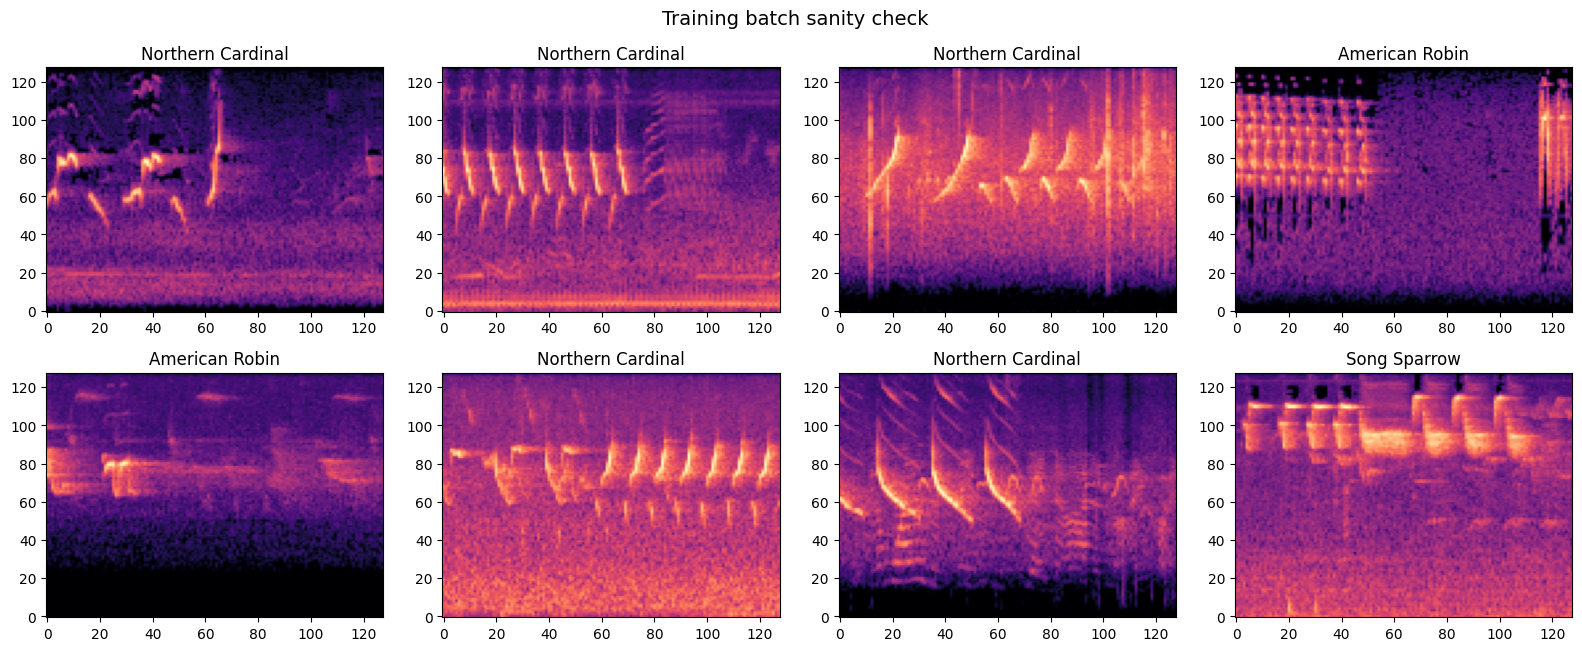

In [11]:
def load_normalization_stats() -> Tuple[Optional[float], Optional[float]]:   # weight initzlization prefers N(0,1) type of data. Allows diffusion with noise step of N(0,1)
    path = PROJECT_ROOT / cfg.NORMALIZATION_STATS
    if not path.exists():
        print("Normalization statistics not found; plots use normalized units:", path)
        return None, None
    with path.open("r", encoding="utf-8") as handle:
        stats = json.load(handle)
    mean_keys = ("mean_db", "mean", "train_mean", "global_mean", "mu_train")
    std_keys = ("std_db", "std", "train_std", "global_std", "sigma_train")
    mean = next((float(stats[key]) for key in mean_keys if key in stats), None)
    std = next((float(stats[key]) for key in std_keys if key in stats), None)
    return mean, std


TRAIN_MEAN, TRAIN_STD = load_normalization_stats()
print("Training normalization mean/std:", TRAIN_MEAN, TRAIN_STD)


def to_display_scale(x: torch.Tensor) -> np.ndarray:
    array = x.detach().cpu().float().numpy()
    if TRAIN_MEAN is not None and TRAIN_STD is not None:
        array = array * TRAIN_STD + TRAIN_MEAN
    return array


def show_spectrogram_grid(tensors: torch.Tensor, labels: torch.Tensor, title: str, max_items: int = 8) -> None:
    count = min(max_items, len(tensors))
    cols = min(4, count)
    rows = math.ceil(count / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.3 * rows), squeeze=False)
    for index, axis in enumerate(axes.flat):
        axis.axis("off")
        if index >= count:
            continue
        axis.imshow(to_display_scale(tensors[index, 0]), origin="lower", aspect="auto", cmap="magma")
        axis.set_title(id_to_label[int(labels[index])])
        axis.axis("on")
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()


show_spectrogram_grid(x_batch, y_batch, "Training batch sanity check")

## Diffusion schedule

Forward process `q(x_t | x_0)` in closed form with a **cosine** beta schedule. Because the
`processed/` tensors are globally standardized (roughly zero-mean / unit-variance), the terminal
`x_T` already matches `N(0, I)`, so no extra rescaling is needed.

In [12]:
#  cumulative signal ᾱ_t as a cosine curve and back-solves β √(1-ᾱ_t)
def cosine_beta_schedule(timesteps: int, s: float = 0.008) -> torch.Tensor:   
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float64) / timesteps 
    alphas_cumprod = torch.cos((x + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return betas.clamp(1e-8, 0.999).float()


def linear_beta_schedule(timesteps: int) -> torch.Tensor:  #  original DDPM 
    return torch.linspace(1e-4, 0.02, timesteps)


T = int(cfg.NUM_TIMESTEPS)
if cfg.BETA_SCHEDULE == "cosine":
    betas = cosine_beta_schedule(T).to(DEVICE)
else:
    betas = linear_beta_schedule(T).to(DEVICE)

alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)
alpha_bar_prev = F.pad(alpha_bar[:-1], (1, 0), value=1.0)
sqrt_alpha_bar = alpha_bar.sqrt()
sqrt_one_minus_alpha_bar = (1.0 - alpha_bar).sqrt()
sqrt_recip_alphas = torch.rsqrt(alphas)
posterior_variance = (betas * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)).clamp(min=1e-20)


def extract(values: torch.Tensor, t: torch.Tensor, x_shape) -> torch.Tensor:           
    out = values.gather(0, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))


def q_sample(x0: torch.Tensor, t: torch.Tensor, noise: torch.Tensor) -> torch.Tensor:  # for an issue of timing 
    return (
        extract(sqrt_alpha_bar, t, x0.shape) * x0
        + extract(sqrt_one_minus_alpha_bar, t, x0.shape) * noise
    )

## Model: compact conditional U-Net

Predicts the added noise `epsilon`. Conditioning = sinusoidal **timestep** （MMDP）embedding + a learned
**class** embedding (with an extra "null" row for classifier-free guidance), injected into every
residual block (FiLM). Self-attention is applied only at the 16x16 resolution to keep compute and
memory modest. On CPU the width is halved automatically (see the CPU preset in the config cell).

The following shows the loss function of training. We are training the noise parameter, with a ground truth: the parameter of `epsilon` that we choes at the forward diffusion process. The U-net convolution netowrk is estimating the `epsilon`. 

$$
\mathcal{L} = \mathbb{E}_{x_0,\, t,\, \varepsilon}
\Big[\; \big\| \varepsilon - \varepsilon_\theta(x_t,\, t,\, c) \big\|^2 \;\Big],
\qquad
x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon,
\quad \varepsilon \sim \mathcal{N}(0, I)
$$

In [13]:
def groups_for(channels: int, max_groups: int = 8) -> int:
    for groups in range(min(max_groups, channels), 0, -1):
        if channels % groups == 0:
            return groups
    return 1


def make_grad_scaler(enabled: bool):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_context(enabled: bool):
    try:
        return torch.amp.autocast(device_type=DEVICE.type, enabled=enabled)
    except AttributeError:
        return torch.cuda.amp.autocast(enabled=enabled)

In [14]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(half, device=t.device).float() / (half - 1)
        )
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResBlock(nn.Module):
    """Residual block with FiLM-style timestep/class conditioning."""

    def __init__(self, in_channels: int, out_channels: int, emb_dim: int, dropout: float = 0.0):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups_for(in_channels), in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        #Feature-wise Linear Modulation a linear decompose of embedding 256 
        self.emb_proj = nn.Linear(emb_dim, out_channels * 2) 
        self.norm2 = nn.GroupNorm(groups_for(out_channels), out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.skip = (
            nn.Conv2d(in_channels, out_channels, 1)
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x: torch.Tensor, emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(F.silu(self.norm1(x)))
        scale, shift = self.emb_proj(F.silu(emb)).chunk(2, dim=1)
        h = self.norm2(h) * (1 + scale[:, :, None, None]) + shift[:, :, None, None]
        h = self.conv2(self.dropout(F.silu(h)))
        return h + self.skip(x)


class AttnBlock(nn.Module):
    """Single-head self-attention over spatial positions."""

    def __init__(self, channels: int):
        super().__init__()
        self.norm = nn.GroupNorm(groups_for(channels), channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, h, w = x.shape
        q, k, v = self.qkv(self.norm(x)).chunk(3, dim=1)
        q = q.reshape(b, c, h * w).permute(0, 2, 1)
        k = k.reshape(b, c, h * w)
        attn = torch.softmax(q @ k / math.sqrt(c), dim=-1)
        v = v.reshape(b, c, h * w).permute(0, 2, 1)
        out = (attn @ v).permute(0, 2, 1).reshape(b, c, h, w)
        return x + self.proj(out)


class Downsample(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, 4, stride=2, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, 3, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(F.interpolate(x, scale_factor=2, mode="nearest"))


class ConditionalUNet(nn.Module):
    """Compact class-conditional U-Net that predicts the diffusion noise (epsilon)."""

    def __init__(
        self,
        in_channels: int = 1,
        base: int = 64,
        dim_mults=(1, 2, 4, 4),
        num_classes: int = 3,
        num_res_blocks: int = 2,
        attn_resolutions=(16,),
        image_size: int = 128,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.num_classes = num_classes
        emb_dim = base * 4
        # we use a small MLP ti program the timesetep determined by the cos function (MMDP)
        self.time_mlp = nn.Sequential(    
            #sine sampling for determine time
            SinusoidalPosEmb(base),
            #pass the rest into an simple MLP and decide how to use it. 
            nn.Linear(base, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        # One extra embedding row is the "null" token used for classifier-free guidance.
        self.class_emb = nn.Embedding(num_classes + 1, emb_dim)
        # Make the tensor channle length 64 * 128 * 128 
        self.init_conv = nn.Conv2d(in_channels, base, 3, padding=1)

        dims = [base] + [base * m for m in dim_mults]
        in_out = list(zip(dims[:-1], dims[1:]))
        num_resolutions = len(in_out)

        res = image_size
        self.downs = nn.ModuleList()
        for index, (din, dout) in enumerate(in_out):
            is_last = index >= num_resolutions - 1
            use_attn = res in attn_resolutions
            blocks = [ResBlock(din, din, emb_dim, dropout) for _ in range(num_res_blocks)]
            self.downs.append(
                nn.ModuleList(
                    [
                        blocks[0],
                        blocks[1] if num_res_blocks > 1 else ResBlock(din, din, emb_dim, dropout),
                        AttnBlock(din) if use_attn else nn.Identity(),
                        nn.Conv2d(din, dout, 3, padding=1) if is_last else Downsample(din, dout),
                    ]
                )
            )
            if not is_last:
                res = res // 2

        mid_dim = dims[-1]
        self.mid_block1 = ResBlock(mid_dim, mid_dim, emb_dim, dropout)
        self.mid_attn = AttnBlock(mid_dim)
        self.mid_block2 = ResBlock(mid_dim, mid_dim, emb_dim, dropout)

        self.ups = nn.ModuleList()
        for index, (din, dout) in enumerate(reversed(in_out)):
            is_last = index >= num_resolutions - 1
            use_attn = res in attn_resolutions
            self.ups.append(
                nn.ModuleList(
                    [
                        ResBlock(dout + din, dout, emb_dim, dropout),
                        ResBlock(dout + din, dout, emb_dim, dropout),
                        AttnBlock(dout) if use_attn else nn.Identity(),
                        nn.Conv2d(dout, din, 3, padding=1) if is_last else Upsample(dout, din),
                    ]
                )
            )
            if not is_last:
                res = res * 2

        self.final_res = ResBlock(base + base, base, emb_dim, dropout)
        self.final_norm = nn.GroupNorm(groups_for(base), base)
        self.final_conv = nn.Conv2d(base, in_channels, 3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        # embedding of size 256
        emb = self.time_mlp(t) + self.class_emb(labels)
        x = self.init_conv(x)
        residual = x
        skips = []
        for block1, block2, attn, downsample in self.downs:
            x = block1(x, emb)
            #store the shape so we can restore when upsampling 
            skips.append(x)
            x = block2(x, emb)
            x = attn(x)
            #store the shape so we can restore when upsampling
            skips.append(x)
            x = downsample(x)
        x = self.mid_block1(x, emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, emb)
        for block1, block2, attn, upsample in self.ups:
            x = torch.cat([x, skips.pop()], dim=1)
            x = block1(x, emb)
            x = torch.cat([x, skips.pop()], dim=1)
            x = block2(x, emb)
            x = attn(x)
            x = upsample(x)
        x = torch.cat([x, residual], dim=1)
        x = self.final_res(x, emb)
        return self.final_conv(F.silu(self.final_norm(x)))

In [15]:
model = ConditionalUNet(
    in_channels=cfg.INPUT_CHANNELS,
    base=cfg.BASE_CHANNELS,
    dim_mults=cfg.DIM_MULTS,
    num_classes=len(label_to_id),
    num_res_blocks=cfg.NUM_RES_BLOCKS,
    attn_resolutions=tuple(cfg.ATTN_RESOLUTIONS),
    image_size=cfg.IMAGE_SIZE,
    dropout=cfg.DROPOUT,
).to(DEVICE)

parameter_counts = {
    "total": int(sum(p.numel() for p in model.parameters())),
    "trainable": int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
}
print("Parameters:", parameter_counts)

with torch.no_grad():
    dummy_x = torch.randn(2, cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE, device=DEVICE)
    dummy_t = torch.randint(0, T, (2,), device=DEVICE)
    dummy_y = torch.zeros(2, dtype=torch.long, device=DEVICE)
    dummy_out = model(dummy_x, dummy_t, dummy_y)
assert dummy_out.shape == dummy_x.shape, dummy_out.shape
print("Forward-pass shape check passed:", tuple(dummy_out.shape))

Parameters: {'total': 18443841, 'trainable': 18443841}
Forward-pass shape check passed: (2, 1, 128, 128)


## Training objective

$$
\mathcal{L} = \mathbb{E}_{x_0,\, t,\, \varepsilon}
\Big[\; \big\| \varepsilon - \varepsilon_\theta(x_t,\, t,\, c) \big\|^2 \;\Big],
\qquad
x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon,
\quad \varepsilon \sim \mathcal{N}(0, I)
$$

In [16]:
def p_losses(model: nn.Module, x0: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    #this is the CGF is happening. 
    batch = x0.shape[0]
    t = torch.randint(0, T, (batch,), device=x0.device).long()
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)
    if cfg.CFG_DROPOUT_PROB > 0:
        drop = torch.rand(batch, device=x0.device) < cfg.CFG_DROPOUT_PROB
        labels = torch.where(drop, torch.full_like(labels, model.num_classes), labels)
    predicted_noise = model(x_t, t, labels)
    return F.mse_loss(predicted_noise, noise)

## Optimizer, EMA, and checkpoints

In [17]:
class EMA:
    """Exponential moving average of model weights, used for sampling."""

    def __init__(self, model: nn.Module, decay: float):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model: nn.Module) -> None:
        for key, value in model.state_dict().items():
            shadow = self.shadow[key]
            if value.dtype.is_floating_point:
                shadow.mul_(self.decay).add_(value.detach(), alpha=1 - self.decay)
            else:
                shadow.copy_(value)

    def state_dict(self) -> Dict[str, torch.Tensor]:
        return self.shadow

    def copy_to(self, model: nn.Module) -> None:
        model.load_state_dict(self.shadow, strict=True)


optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=cfg.WEIGHT_DECAY)
scaler = make_grad_scaler(AMP_ENABLED)
ema = EMA(model, cfg.EMA_DECAY)


def save_checkpoint(path, epoch, model, optimizer, scaler, ema, history, best_val_loss) -> None:
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "ema_state_dict": ema.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "history": history,
            "best_val_loss": best_val_loss,
            "config": asdict(cfg),
            "label_to_id": label_to_id,
            "parameter_counts": parameter_counts,
        },
        path,
    )


def load_checkpoint(path, model, optimizer=None, scaler=None, ema=None):
    checkpoint = torch.load(path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scaler is not None and "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
    if ema is not None and "ema_state_dict" in checkpoint:
        ema.shadow = {k: v.to(DEVICE) for k, v in checkpoint["ema_state_dict"].items()}
    return checkpoint

## Training loop

In [ ]:
def run_epoch(model, loader, optimizer=None, scaler=None, ema=None, max_batches=None) -> float:
    is_training = optimizer is not None
    model.train(is_training)
    total_loss, sample_count = 0.0, 0
    if is_training:
        optimizer.zero_grad(set_to_none=True)

    for batch_index, (x, labels, _) in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break
        x = x.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        batch_size = len(x)

        with torch.set_grad_enabled(is_training):
            with autocast_context(AMP_ENABLED):
                loss = p_losses(model, x, labels)
            if is_training:
                scaler.scale(loss / cfg.GRAD_ACCUM_STEPS).backward()
                if (batch_index + 1) % cfg.GRAD_ACCUM_STEPS == 0:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    ema.update(model)

        total_loss += float(loss.detach()) * batch_size
        sample_count += batch_size

    if sample_count == 0:
        raise RuntimeError("No samples were processed in this epoch.")
    return total_loss / sample_count


history = {"epoch": [], "train_loss": [], "val_loss": [], "epoch_seconds": []}
best_path = CHECKPOINT_DIR / "conditional_diffusion_best.pt"
last_path = CHECKPOINT_DIR / "conditional_diffusion_last.pt"
start_epoch = 1
best_val_loss = float("inf")
epochs_without_improvement = 0

if cfg.RESUME_FROM_LAST and last_path.exists():
    checkpoint = load_checkpoint(last_path, model, optimizer, scaler, ema)
    start_epoch = int(checkpoint["epoch"]) + 1
    history = checkpoint.get("history", history)
    best_val_loss = float(checkpoint.get("best_val_loss", best_val_loss))
    print(f"Resuming from epoch {start_epoch}")

max_epochs = cfg.SMOKE_TEST_EPOCHS if cfg.SMOKE_TEST else cfg.MAX_EPOCHS
max_batches = cfg.SMOKE_TEST_BATCHES if cfg.SMOKE_TEST else None
training_start = time.perf_counter()

if cfg.RUN_TRAINING:
    for epoch in range(start_epoch, max_epochs + 1):
        epoch_start = time.perf_counter()
        train_loss = run_epoch(model, train_loader, optimizer, scaler, ema, max_batches=max_batches)
        val_loss = run_epoch(model, val_loader, max_batches=max_batches)
        elapsed = time.perf_counter() - epoch_start

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["epoch_seconds"].append(elapsed)

        improved = val_loss < best_val_loss - cfg.MIN_DELTA
        if improved:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            save_checkpoint(best_path, epoch, model, optimizer, scaler, ema, history, best_val_loss)
        else:
            epochs_without_improvement += 1
        save_checkpoint(last_path, epoch, model, optimizer, scaler, ema, history, best_val_loss)

        print(
            f"Epoch {epoch:03d}/{max_epochs:03d} | train={train_loss:.5f} | val={val_loss:.5f} | "
            f"{elapsed:.1f}s" + (" | saved best" if improved else "")
        )
        if epochs_without_improvement >= cfg.EARLY_STOPPING_PATIENCE:
            print(f"Early stopping after {epoch} epochs.")
            break
    print(f"Training elapsed: {(time.perf_counter() - training_start) / 60:.1f} minutes")
else:
    print("RUN_TRAINING is False; no optimization was performed.")

if DEVICE.type == "cuda":
    print(f"Peak allocated CUDA memory: {torch.cuda.max_memory_allocated() / 1024 ** 3:.2f} GB")
else:
    print("Running on CPU (no GPU memory to report).")

Epoch 001/200 | train=0.32369 | val=0.22213 | 298.2s | saved best
Epoch 002/200 | train=0.22335 | val=0.20986 | 13.6s | saved best
Epoch 003/200 | train=0.20071 | val=0.17385 | 9.6s | saved best
Epoch 004/200 | train=0.18666 | val=0.18989 | 9.1s
Epoch 005/200 | train=0.18872 | val=0.16290 | 13.5s | saved best
Epoch 006/200 | train=0.19470 | val=0.17759 | 9.7s
Epoch 007/200 | train=0.19057 | val=0.17382 | 14.0s
Epoch 008/200 | train=0.18002 | val=0.17613 | 13.4s
Epoch 009/200 | train=0.17084 | val=0.18262 | 9.1s
Epoch 010/200 | train=0.17307 | val=0.19426 | 9.1s
Epoch 011/200 | train=0.16395 | val=0.18014 | 9.1s
Epoch 012/200 | train=0.17375 | val=0.18174 | 9.1s
Epoch 013/200 | train=0.17278 | val=0.15711 | 9.1s | saved best
Epoch 014/200 | train=0.18604 | val=0.17295 | 9.3s
Epoch 015/200 | train=0.16704 | val=0.15352 | 13.4s | saved best
Epoch 016/200 | train=0.17167 | val=0.17411 | 9.6s
Epoch 017/200 | train=0.17279 | val=0.17131 | 14.3s
Epoch 018/200 | train=0.16350 | val=0.15403 | 9

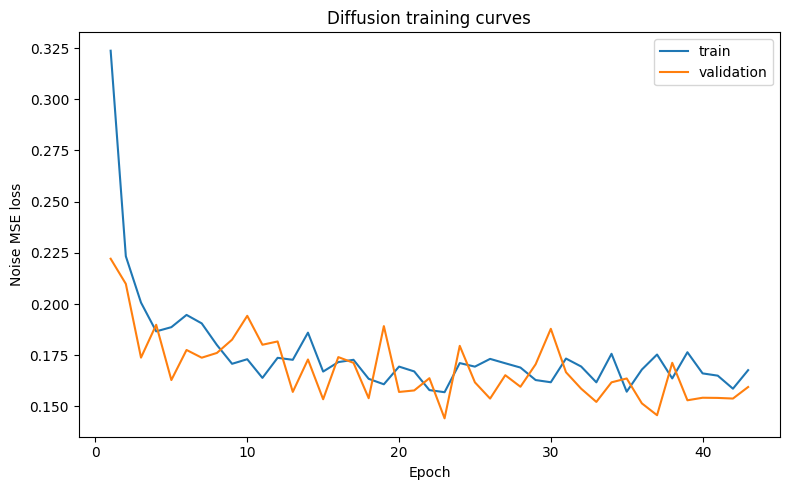

Saved: /content/drive/MyDrive/googlecolab/bird_song_gen/outputs/conditional_diffusion/training_curves.png


In [ ]:
if history["epoch"]:
    fig, axis = plt.subplots(1, 1, figsize=(8, 5))
    axis.plot(history["epoch"], history["train_loss"], label="train")
    axis.plot(history["epoch"], history["val_loss"], label="validation")
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Noise MSE loss")
    axis.set_title("Diffusion training curves")
    axis.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "training_curves.png", dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", OUTPUT_DIR / "training_curves.png")
else:
    print("No training history to plot.")

In [ ]:
# Build a dedicated sampling model that uses the EMA weights of the best checkpoint.
sampling_model = ConditionalUNet(
    in_channels=cfg.INPUT_CHANNELS,
    base=cfg.BASE_CHANNELS,
    dim_mults=cfg.DIM_MULTS,
    num_classes=len(label_to_id),
    num_res_blocks=cfg.NUM_RES_BLOCKS,
    attn_resolutions=tuple(cfg.ATTN_RESOLUTIONS),
    image_size=cfg.IMAGE_SIZE,
    dropout=cfg.DROPOUT,
).to(DEVICE)

if best_path.exists():
    best_checkpoint = load_checkpoint(best_path, model, ema=ema)
    history = best_checkpoint.get("history", history)
    if "ema_state_dict" in best_checkpoint:
        sampling_model.load_state_dict({k: v.to(DEVICE) for k, v in best_checkpoint["ema_state_dict"].items()})
    else:
        sampling_model.load_state_dict(best_checkpoint["model_state_dict"])
    print("Loaded best checkpoint from epoch", best_checkpoint["epoch"])
else:
    sampling_model.load_state_dict(model.state_dict())
    print("No best checkpoint found; sampling from the in-memory model instead.")

sampling_model.eval()

Loaded best checkpoint from epoch 23


ConditionalUNet(
  (time_mlp): Sequential(
    (0): SinusoidalPosEmb()
    (1): Linear(in_features=64, out_features=256, bias=True)
    (2): SiLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
  )
  (class_emb): Embedding(4, 256)
  (init_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0): ModuleList(
      (0-1): 2 x ResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (emb_proj): Linear(in_features=256, out_features=128, bias=True)
        (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (skip): Identity()
      )
      (2): Identity()
      (3): Downsample(
        (conv): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      )
    )
    (1): ModuleList(
 

## Sampling and generation

`sample_batch` runs the configured sampler (DDIM by default) with classifier-free guidance.
Generated spectrograms are written to `outputs/conditional_diffusion/generated_npy/` with a
`generated_manifest.csv` whose schema matches the VAE's, so the Stage-6 evaluator works unchanged.

In [ ]:
def predict_eps(model, x, t, labels, guidance):
    if guidance is not None and guidance != 1.0:
        null_labels = torch.full_like(labels, model.num_classes)
        eps_cond = model(x, t, labels)
        eps_uncond = model(x, t, null_labels)
        return eps_uncond + guidance * (eps_cond - eps_uncond)
    return model(x, t, labels)


@torch.no_grad()
def ddpm_sample(model, labels, guidance=1.0):
    model.eval()
    batch = len(labels)
    x = torch.randn(batch, cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE, device=DEVICE)
    for i in reversed(range(T)):
        t = torch.full((batch,), i, device=DEVICE, dtype=torch.long)
        eps = predict_eps(model, x, t, labels, guidance)
        mean = extract(sqrt_recip_alphas, t, x.shape) * (
            x - extract(betas, t, x.shape) / extract(sqrt_one_minus_alpha_bar, t, x.shape) * eps
        )
        if i > 0:
            x = mean + extract(posterior_variance, t, x.shape).sqrt() * torch.randn_like(x)
        else:
            x = mean
    return x


@torch.no_grad()
def ddim_sample(model, labels, guidance=1.0, steps=None, eta=None):
    model.eval()
    steps = int(steps or cfg.DDIM_STEPS)
    eta = cfg.DDIM_ETA if eta is None else eta
    batch = len(labels)
    x = torch.randn(batch, cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE, device=DEVICE)
    seq = torch.linspace(0, T - 1, steps, device=DEVICE).round().long().tolist()
    seq = list(reversed(seq))
    for position, i in enumerate(seq):
        t = torch.full((batch,), i, device=DEVICE, dtype=torch.long)
        eps = predict_eps(model, x, t, labels, guidance)
        ab_t = extract(alpha_bar, t, x.shape)
        x0 = (x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()
        if cfg.CLAMP_SAMPLES is not None:
            x0 = x0.clamp(-cfg.CLAMP_SAMPLES, cfg.CLAMP_SAMPLES)
        i_next = seq[position + 1] if position + 1 < len(seq) else -1
        if i_next < 0:
            x = x0
        else:
            t_next = torch.full((batch,), i_next, device=DEVICE, dtype=torch.long)
            ab_next = extract(alpha_bar, t_next, x.shape)
            sigma = eta * (((1 - ab_next) / (1 - ab_t)) * (1 - ab_t / ab_next)).clamp(min=0).sqrt()
            x = (
                ab_next.sqrt() * x0
                + (1 - ab_next - sigma ** 2).clamp(min=0).sqrt() * eps
                + sigma * torch.randn_like(x)
            )
    return x


def sample_batch(model, labels, guidance=None):
    guidance = cfg.GUIDANCE_WEIGHT if guidance is None else guidance
    if cfg.SAMPLER == "ddpm":
        return ddpm_sample(model, labels, guidance=guidance)
    return ddim_sample(model, labels, guidance=guidance)

Saved generated manifest: /content/drive/MyDrive/googlecolab/bird_song_gen/outputs/conditional_diffusion/generated_manifest.csv


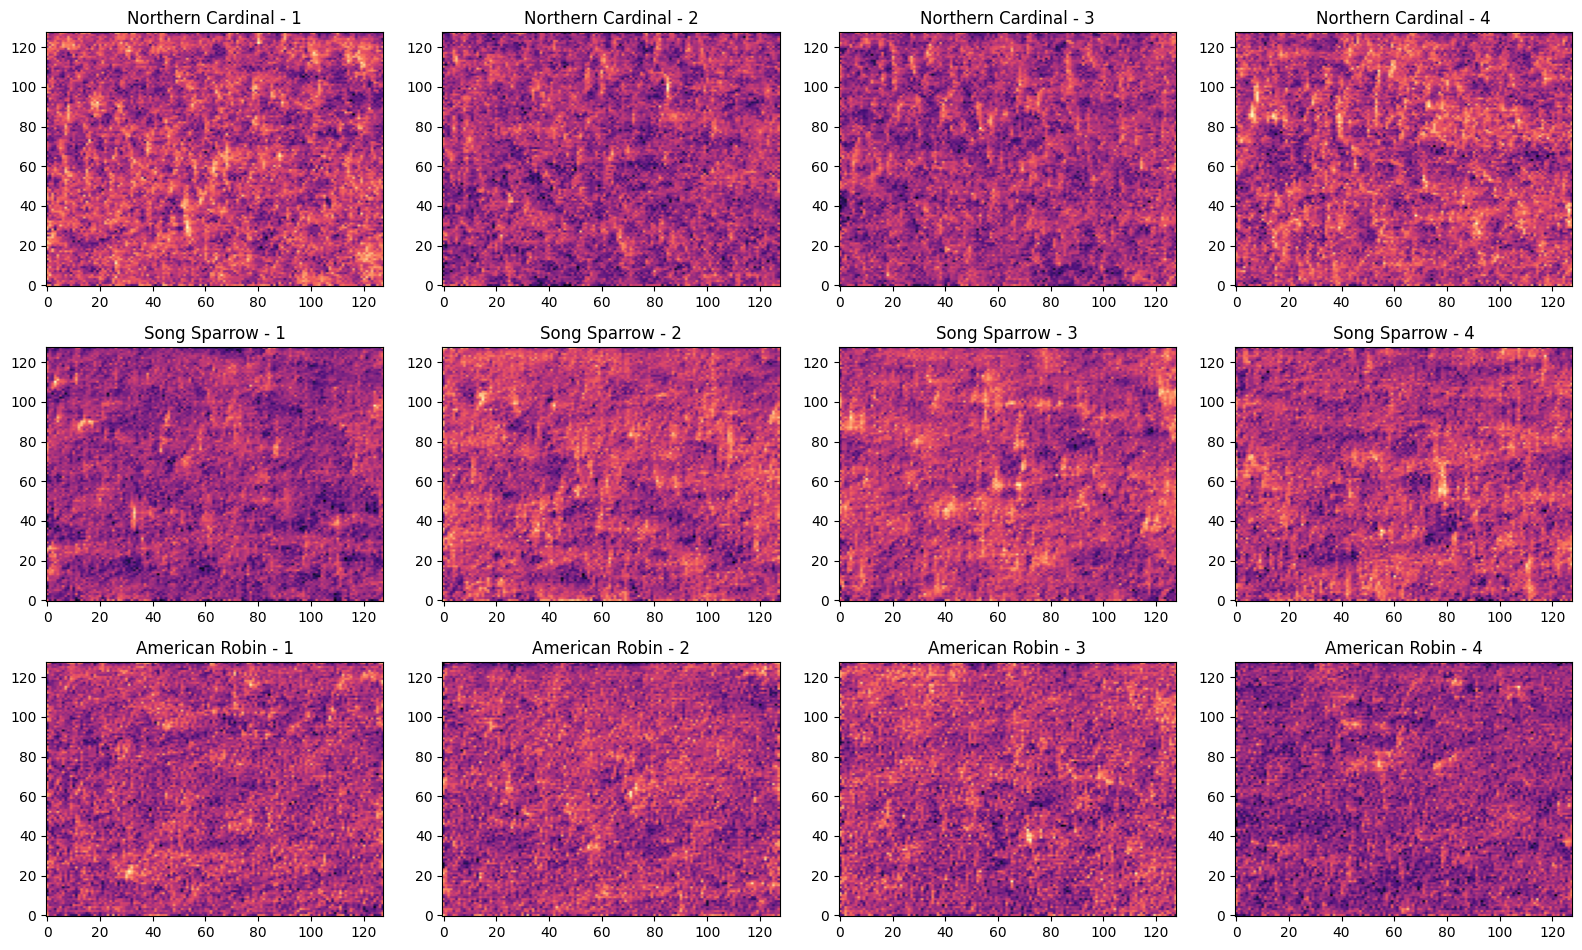

Saved: /content/drive/MyDrive/googlecolab/bird_song_gen/outputs/conditional_diffusion/conditional_samples.png


In [ ]:
@torch.no_grad()
def generate_and_save_samples(model, samples_per_species: int, guidance=None):
    labels = torch.arange(len(label_to_id), device=DEVICE).repeat_interleave(samples_per_species)
    samples = sample_batch(model, labels, guidance=guidance)

    generated_dir = OUTPUT_DIR / "generated_npy"
    generated_dir.mkdir(parents=True, exist_ok=True)
    records = []
    for index, (sample, label) in enumerate(zip(samples, labels)):
        label_id = int(label)
        species = id_to_label[label_id]
        species_slug = species.lower().replace(" ", "_").replace("'", "")
        species_index = index % samples_per_species
        filename = f"diff_{species_slug}_{species_index:03d}.npy"
        path = generated_dir / filename
        np.save(path, sample.detach().cpu().float().numpy().astype(np.float32))
        records.append(
            {
                "filename": filename,
                "spec_path": str(path.resolve()),
                "name": species,
                "label_id": label_id,
                "source_model": "conditional_diffusion",
            }
        )

    manifest_path = OUTPUT_DIR / "generated_manifest.csv"
    pd.DataFrame(records).to_csv(manifest_path, index=False)
    print("Saved generated manifest:", manifest_path)
    return samples.cpu(), labels.cpu()


def plot_generated_samples(samples, labels, samples_per_species_to_show: int = 4) -> None:
    rows = len(label_to_id)
    cols = samples_per_species_to_show
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.2 * rows), squeeze=False)
    for label_id in range(rows):
        indices = torch.where(labels == label_id)[0][:cols]
        for col, index in enumerate(indices):
            axes[label_id, col].imshow(
                to_display_scale(samples[index, 0]), origin="lower", aspect="auto", cmap="magma"
            )
            axes[label_id, col].set_title(f"{id_to_label[label_id]} - {col + 1}")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "conditional_samples.png", dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", OUTPUT_DIR / "conditional_samples.png")


samples_to_generate = 2 if cfg.SMOKE_TEST else cfg.SAMPLES_PER_SPECIES
generated_samples, generated_labels = generate_and_save_samples(sampling_model, samples_to_generate)
plot_generated_samples(generated_samples, generated_labels)

## Reverse-denoising trajectory

The diffusion analogue of the VAE's reconstruction panel: start from pure noise and visualize the
predicted clean spectrogram (`x0`) at a few points along the DDIM reverse trajectory, one row per
species.

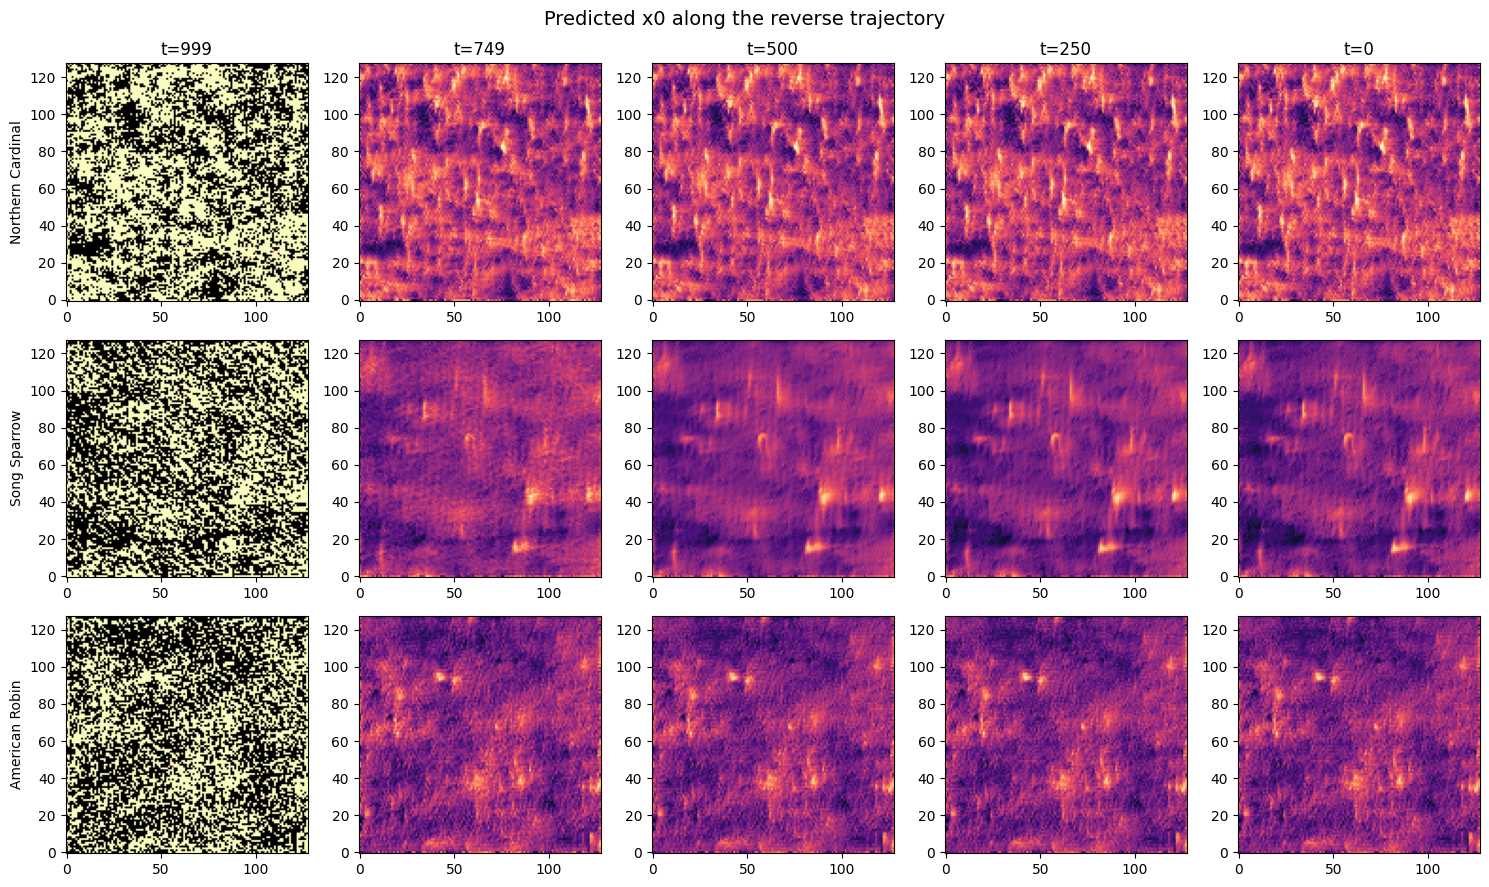

Saved: /content/drive/MyDrive/googlecolab/bird_song_gen/outputs/conditional_diffusion/denoising_trajectory.png


In [ ]:
@torch.no_grad()
def denoising_trajectory(model, labels, steps=8, guidance=None, snapshots=5):
    guidance = cfg.GUIDANCE_WEIGHT if guidance is None else guidance
    batch = len(labels)
    x = torch.randn(batch, cfg.INPUT_CHANNELS, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE, device=DEVICE)
    seq = list(reversed(torch.linspace(0, T - 1, steps, device=DEVICE).round().long().tolist()))
    snapshot_positions = set(np.linspace(0, len(seq) - 1, snapshots).round().astype(int).tolist())
    frames = []
    for position, i in enumerate(seq):
        t = torch.full((batch,), i, device=DEVICE, dtype=torch.long)
        eps = predict_eps(model, x, t, labels, guidance)
        ab_t = extract(alpha_bar, t, x.shape)
        x0 = (x - (1 - ab_t).sqrt() * eps) / ab_t.sqrt()
        if cfg.CLAMP_SAMPLES is not None:
            x0 = x0.clamp(-cfg.CLAMP_SAMPLES, cfg.CLAMP_SAMPLES)
        i_next = seq[position + 1] if position + 1 < len(seq) else -1
        if i_next < 0:
            x = x0
        else:
            t_next = torch.full((batch,), i_next, device=DEVICE, dtype=torch.long)
            ab_next = extract(alpha_bar, t_next, x.shape)
            x = ab_next.sqrt() * x0 + (1 - ab_next).sqrt() * eps
        if position in snapshot_positions:
            frames.append((int(i), x0.detach().cpu()))
    return frames


traj_labels = torch.arange(len(label_to_id), device=DEVICE)
frames = denoising_trajectory(sampling_model, traj_labels, steps=max(8, cfg.DDIM_STEPS // 4))

fig, axes = plt.subplots(len(label_to_id), len(frames), figsize=(3 * len(frames), 3 * len(label_to_id)), squeeze=False)
for row in range(len(label_to_id)):
    for col, (timestep, frame) in enumerate(frames):
        axes[row, col].imshow(to_display_scale(frame[row, 0]), origin="lower", aspect="auto", cmap="magma")
        if row == 0:
            axes[row, col].set_title(f"t={timestep}")
        if col == 0:
            axes[row, col].set_ylabel(id_to_label[row])
fig.suptitle("Predicted x0 along the reverse trajectory", fontsize=14)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "denoising_trajectory.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", OUTPUT_DIR / "denoising_trajectory.png")

## Optional: spectrogram -> audio (Griffin-Lim vocoder baseline)

Set `cfg.EXPORT_AUDIO = True` to invert generated spectrograms to `.wav` using Griffin-Lim. This is
a deterministic vocoder **baseline** (the proposal's "vocoder reconstruction baseline"), not a neural
vocoder. Inversion is approximate because it undoes the standardization back to dB and treats the
result as a mel-power spectrogram; it is intended for listening tests, not exact reconstruction.

In [ ]:
if cfg.EXPORT_AUDIO:
    import librosa
    import soundfile as sf

    with (PROJECT_ROOT / cfg.SPECTROGRAM_CONFIG).open("r", encoding="utf-8") as handle:
        spec_cfg = json.load(handle)

    audio_dir = OUTPUT_DIR / "generated_audio"
    audio_dir.mkdir(parents=True, exist_ok=True)

    def spectrogram_to_audio(x: torch.Tensor) -> np.ndarray:
        db = to_display_scale(x[0])                       # (128, 128) log-mel in dB
        mel_power = librosa.db_to_power(db.astype(np.float64))
        return librosa.feature.inverse.mel_to_audio(
            mel_power,
            sr=spec_cfg["sample_rate"],
            n_fft=spec_cfg["n_fft"],
            hop_length=spec_cfg["hop_length"],
            n_iter=cfg.GRIFFIN_LIM_ITERS,
            fmin=spec_cfg.get("f_min", 0.0),
            fmax=spec_cfg.get("f_max", spec_cfg["sample_rate"] / 2),
        )

    audio_labels = torch.arange(len(label_to_id), device=DEVICE).repeat_interleave(cfg.AUDIO_SAMPLES_PER_SPECIES)
    audio_samples = sample_batch(sampling_model, audio_labels)
    for index, (sample, label) in enumerate(zip(audio_samples, audio_labels)):
        species = id_to_label[int(label)]
        slug = species.lower().replace(" ", "_").replace("'", "")
        waveform = spectrogram_to_audio(sample.cpu())
        out_path = audio_dir / f"diff_{slug}_{index % cfg.AUDIO_SAMPLES_PER_SPECIES:03d}.wav"
        sf.write(out_path, waveform, spec_cfg["sample_rate"])
    print("Wrote audio clips to:", audio_dir)
else:
    print("EXPORT_AUDIO is False; skipping audio export. Set cfg.EXPORT_AUDIO = True to enable.")

Wrote audio clips to: /content/drive/MyDrive/googlecolab/bird_song_gen/outputs/conditional_diffusion/generated_audio


## Run summary

In [ ]:
run_summary = {
    "model": "conditional_diffusion",
    "num_timesteps": T,
    "beta_schedule": cfg.BETA_SCHEDULE,
    "sampler": cfg.SAMPLER,
    "guidance_weight": cfg.GUIDANCE_WEIGHT,
    "parameter_counts": parameter_counts,
    "best_val_loss": best_val_loss if best_val_loss != float("inf") else None,
    "epochs_trained": history["epoch"][-1] if history["epoch"] else 0,
    "best_checkpoint": str(best_path.resolve()) if best_path.exists() else None,
    "output_dir": str(OUTPUT_DIR.resolve()),
    "target_species": list(cfg.TARGET_SPECIES),
    "smoke_test": cfg.SMOKE_TEST,
}
summary_path = OUTPUT_DIR / "run_summary.json"
with summary_path.open("w", encoding="utf-8") as handle:
    json.dump(run_summary, handle, indent=2)
print(json.dumps(run_summary, indent=2))
print("Saved:", summary_path)

{
  "model": "conditional_diffusion",
  "num_timesteps": 1000,
  "beta_schedule": "cosine",
  "sampler": "ddim",
  "guidance_weight": 3.0,
  "parameter_counts": {
    "total": 18443841,
    "trainable": 18443841
  },
  "best_val_loss": 0.14420514203507548,
  "epochs_trained": 23,
  "best_checkpoint": "/content/drive/MyDrive/googlecolab/bird_song_gen/checkpoints/conditional_diffusion/conditional_diffusion_best.pt",
  "output_dir": "/content/drive/MyDrive/googlecolab/bird_song_gen/outputs/conditional_diffusion",
  "target_species": [
    "Northern Cardinal",
    "Song Sparrow",
    "American Robin"
  ],
  "smoke_test": false
}
Saved: /content/drive/MyDrive/googlecolab/bird_song_gen/outputs/conditional_diffusion/run_summary.json


In [ ]:
if colab == True: 
    from google.colab import drive
    drive.flush_and_unmount()
    drive.mount('/content/drive')

Mounted at /content/drive
